In [1]:
%cd ..

/home/aru/Work/shome2023notebook


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
data = pd.concat([
    pd.read_csv("data/shome2023notebook/GH_sample-annot.csv"),
    pd.read_csv("data/shome2023notebook/KG_sample-annot.csv")
], ignore_index=True)
data.head()

,notebook,stmt,source,CALL,CGH,CKG,EC,Intent,Stage,Notes
0,data/assert_notebooks/lepmik/meta-reinforcemen...,np.unique(env._s_hist[:-1][np.diff(env._s_hist...,GH,-1,-2.0,NaN,NaN,EXP-COMPUTE,EVAL,RL context. Diagnostic to identify which state...
1,data/assert_notebooks/dhuynh95/cryptotree/nbs/...,"(comparator.weight.data, comparator.bias.data)",GH,117,-2.0,NaN,NaN,EXP-INSPECT,EVAL,Check learned weights and bias of model.
2,data/assert_notebooks/nikohou/LoadLanguageMode...,assert dim % 2 == 0,GH,992,-2.0,NaN,NaN,VAL-EQ,MODEL,Defined inside `__init__` method of a neural n...
3,data/assert_notebooks/EricCousineau-TRI/repro/...,assert activated.ndim > 1,GH,1021,-2.0,NaN,NaN,VAL-SHAPE,MODEL,"Ensure activation tensor is a batch (2D), not ..."
4,data/assert_notebooks/microsoft/Reactors/learn...,assert subscription_key,GH,1025,-2.0,NaN,NOINT,NaN,NaN,NaN


Remove the rows that were excluded during analysis.

In [19]:
data.shape

(906, 10)

In [20]:
data = data.loc[data["EC"].isna()]
data.shape

(815, 10)

Split the `Intent` into two columns.

In [21]:
data["Type"] = data["Intent"].map(lambda x: x.split("-")[-1], na_action="ignore")
data["Intent"] = data["Intent"].map(lambda x: x.split("-")[0], na_action="ignore")
data.head()

,notebook,stmt,source,CALL,CGH,CKG,EC,Intent,Stage,Notes,Type
0,data/assert_notebooks/lepmik/meta-reinforcemen...,np.unique(env._s_hist[:-1][np.diff(env._s_hist...,GH,-1,-2.0,NaN,NaN,EXP,EVAL,RL context. Diagnostic to identify which state...,COMPUTE
1,data/assert_notebooks/dhuynh95/cryptotree/nbs/...,"(comparator.weight.data, comparator.bias.data)",GH,117,-2.0,NaN,NaN,EXP,EVAL,Check learned weights and bias of model.,INSPECT
2,data/assert_notebooks/nikohou/LoadLanguageMode...,assert dim % 2 == 0,GH,992,-2.0,NaN,NaN,VAL,MODEL,Defined inside `__init__` method of a neural n...,EQ
3,data/assert_notebooks/EricCousineau-TRI/repro/...,assert activated.ndim > 1,GH,1021,-2.0,NaN,NaN,VAL,MODEL,"Ensure activation tensor is a batch (2D), not ...",SHAPE
5,data/assert_notebooks/H-E-L-P/XID_plus/docs/bu...,"plt.plot(test_x, test_y, 'ro', alpha=0.5)",GH,614,-2.0,NaN,NaN,EXP,EVAL,Visually inspect actual vs. predictions of the...,INSPECT


# Function intent of validation statements (Dimension A)

## Top-level intent split (VAL vs EXP vs DOC)

In [95]:
sns.set_theme(
    context="talk",
    palette="colorblind",
    style="whitegrid",
)

In [89]:
def annot_count_with_percent(ax) -> None:
    """Annotate each bar with count and percentage relative to hue size."""
    for container in ax.containers:
        total = sum(p.get_height() for p in container)
        labels = [
            f"{int(p.get_height())} ({100 * p.get_height() / total:.1f}%)"
            for p in container
        ]
        ax.bar_label(container, labels=labels, fontsize=10.0)

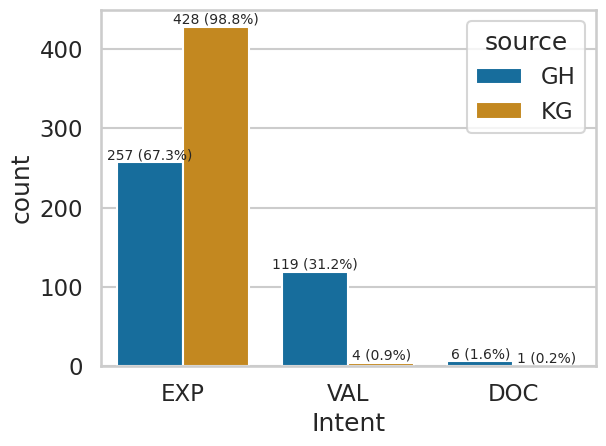

In [96]:
ax = sns.countplot(
    data=data,
    x='Intent',
    order=data["Intent"].value_counts().index,
    hue='source'
)
annot_count_with_percent(ax)
ax.get_figure().tight_layout()

## EXP breakdown

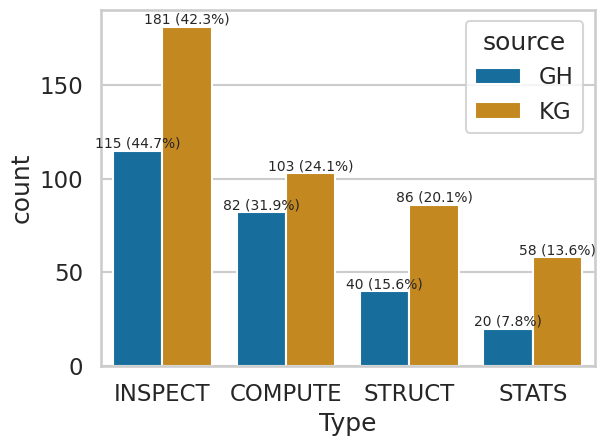

In [97]:
d = data[data["Intent"] == "EXP"]
ax = sns.countplot(
    data=d,
    x="Type",
    order=d["Type"].value_counts().index,
    hue="source",
)
annot_count_with_percent(ax)
ax.get_figure().tight_layout()

## VAL breakdown
GH focused since KG only contains 4 assertions.

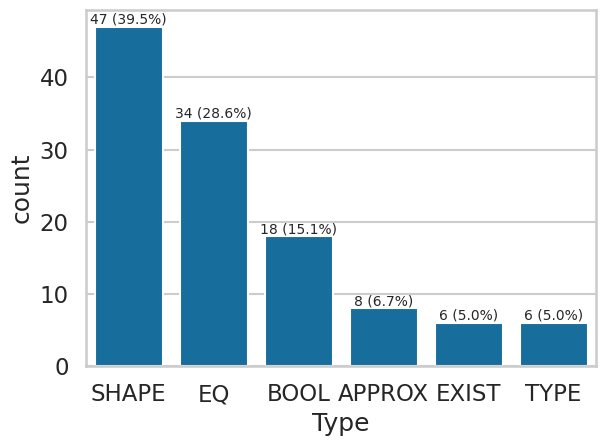

In [99]:
d = data[(data["source"] == "GH") & (data["Intent"] == "VAL")]
ax = sns.countplot(
    data=d,
    x="Type",
    order=d["Type"].value_counts().index,
)
annot_count_with_percent(ax)
ax.get_figure().tight_layout()

# ML pipeline stage distribution (Dimension B)

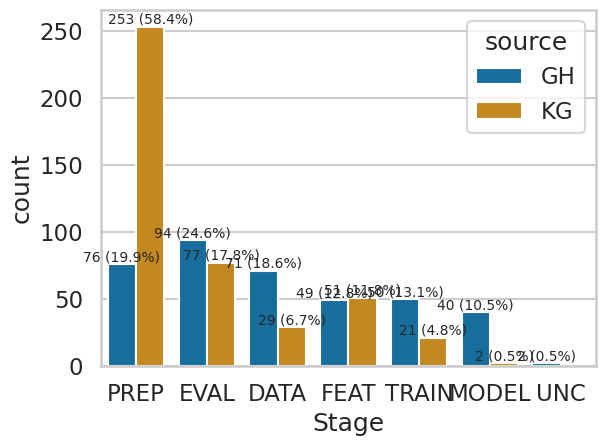

In [105]:
ax = sns.countplot(
    data=data,
    x="Stage",
    hue="source",
    order=data["Stage"].value_counts().index,
)
annot_count_with_percent(ax)
ax.get_figure().tight_layout()